# 02 - Ekstraksi dan Pemantauan Dinamika Ekologis Mangrove Pantura (2021–2024)
**Kompetisi**: Airlangga Statistics Essay Competition (ASEC) 2026 — Arsen Unair  
**Tim Peneliti**: Mutia & Reno (Universitas Gadjah Mada)  
**Kategori**: Pilar 2 — Ekologis & Ketahanan Hayati Pesisir (*Ecological & Mangrove Resilience Dimension*)  
**Kepatuhan Temporal**: 100% Mematuhi Aturan 5 Tahun Terakhir (Data Observasi Sensor $\ge 2021$)  

---

### Deskripsi & Metodologi Komprehensif
Notebook ini secara mendalam mengkaji dimensi ekologis melalui pendekatan *Dual-Dataset Validation* (GMW v4.1.12 + ESA WorldCover 10m) yang terintegrasi:
1. **Ekstraksi Luasan Mangrove Tahunan Resmi (GMW v4.1.12, 2021 s.d. 2024)**:
   - Membaca tile resmi *Global Mangrove Watch* v4.1.12 (`Dataset/02_Ekologis_Mangrove/GMW_v4112_Annual_1985_2025/`).
   - Mengisolasi Band 36 (2021), 37 (2022), 38 (2023), dan 39 (2024) untuk menghitung luasan aktual dalam Hektar (Ha) serta dinamika laju perubahannya ($\Delta\text{Luas}$).
2. **Validasi Silang Resolusi Tinggi 10m & Analisis Fragmentasi Lanskap**:
   - Membaca Band 2 (`mangrove_2021`, Class 95) dari raster 10m ESA WorldCover 2021.
   - Menerapkan algoritma *Connected Components Labeling* untuk menghitung metrik ekologi lanskap: jumlah rumpun (*number of patches*), rata-rata luas rumpun, dan rumpun terluas.
   - Membandingkan hasil luasan GMW 30m vs ESA 10m untuk membuktikan mengapa sensor mikro resolusi tinggi krusial mendeteksi mangrove yang terjepit dan terfragmentasi parah.
3. **Pemantauan Vitalitas Kanopi Multi-Temporal (Sentinel-2 2021 s.d. 2024)**:
   - Mengekstrak deret waktu 4 tahun indeks klorofil hijau (**NDVI**) dan kadar air tajuk daun (**NDMI**).
   - Menghitung laju perubahan 3 tahun ($\Delta \text{NDVI}$ & $\Delta \text{NDMI}$) untuk mendeteksi stres salinitas dan klorosis akibat subsidensi tanah.
4. **Visualisasi Publikasi & Ekspor Terstruktur**:
   - Visualisasi: `Codes/Outputs/Visualisasi/`
   - Tabel Statistik: `Codes/Outputs/Statistik/`
   - Dataset Ekstraksi: `Dataset/04_Tabel_Ekstraksi_CSV_Excel/`

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import tifffile
from scipy.ndimage import label
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Pandas version:", pd.__version__)
print("Numpy version:", np.__version__)
print("Seluruh pustaka analisis ekologis berhasil dimuat!")

Pandas version: 2.3.3
Numpy version: 2.3.5
Seluruh pustaka analisis ekologis berhasil dimuat!


## 1. Konfigurasi Path Direktori Dataset & Output Terstruktur
Menghubungkan jalur dataset GMW v4.1.12 lokal, citra 16-band hasil GEE, serta mendefinisikan direktori penyimpanan output modular.

In [2]:
cwd = os.getcwd()
if os.path.exists(os.path.join(cwd, 'Dataset')):
    BASE_DIR = os.path.abspath(cwd)
elif os.path.exists(os.path.join(cwd, '..', '..', 'Dataset')):
    BASE_DIR = os.path.abspath(os.path.join(cwd, '..', '..'))
elif os.path.exists(os.path.join(cwd, '..', 'Dataset')):
    BASE_DIR = os.path.abspath(os.path.join(cwd, '..'))
else:
    BASE_DIR = os.path.abspath(os.path.join(cwd, '..', '..'))

DATASET_DIR = os.path.join(BASE_DIR, 'Dataset')
DIR_EKOLOGIS = os.path.join(DATASET_DIR, '02_Ekologis_Mangrove')
DIR_GMW = os.path.join(DIR_EKOLOGIS, 'GMW_v4112_Annual_1985_2025')
DIR_RASTER = os.path.join(DATASET_DIR, '03_Raster_Satelit_10m_2021_2024')
DIR_OUT_TABLES = os.path.join(DATASET_DIR, '04_Tabel_Ekstraksi_CSV_Excel')

DIR_CODES = os.path.join(BASE_DIR, 'Codes')
DIR_OUTPUTS = os.path.join(DIR_CODES, 'Outputs')
DIR_VISUALISASI = os.path.join(DIR_OUTPUTS, 'Visualisasi')
DIR_STATISTIK = os.path.join(DIR_OUTPUTS, 'Statistik')

os.makedirs(DIR_OUT_TABLES, exist_ok=True)
os.makedirs(DIR_VISUALISASI, exist_ok=True)
os.makedirs(DIR_STATISTIK, exist_ok=True)

print("Path Basis Proyek:", BASE_DIR)
print("Folder Input GMW v4.1.12:", DIR_GMW)
print("Folder Input Raster 16 Band:", DIR_RASTER)
print("Folder Output Visualisasi:", DIR_VISUALISASI)
print("Folder Output Statistik:", DIR_STATISTIK)
print("Folder Output Dataset:", DIR_OUT_TABLES)
print("Status: Seluruh direktori siap digunakan!")

Path Basis Proyek: D:\Kuliah\Lomba\ASEC Arsen Unair 2026
Folder Input GMW v4.1.12: D:\Kuliah\Lomba\ASEC Arsen Unair 2026\Dataset\02_Ekologis_Mangrove\GMW_v4112_Annual_1985_2025
Folder Input Raster 16 Band: D:\Kuliah\Lomba\ASEC Arsen Unair 2026\Dataset\03_Raster_Satelit_10m_2021_2024
Folder Output Visualisasi: D:\Kuliah\Lomba\ASEC Arsen Unair 2026\Codes\Outputs\Visualisasi
Folder Output Statistik: D:\Kuliah\Lomba\ASEC Arsen Unair 2026\Codes\Outputs\Statistik
Folder Output Dataset: D:\Kuliah\Lomba\ASEC Arsen Unair 2026\Dataset\04_Tabel_Ekstraksi_CSV_Excel
Status: Seluruh direktori siap digunakan!


## 2. Ekstraksi Luasan Mangrove Tahunan Resmi (Global Mangrove Watch v4.1.12, 2021–2024)
Membaca tile raster 41 band GMW v4.1.12 pada koordinat ROI 5 wilayah studi, mengekstrak Band 36 (2021) s.d. Band 39 (2024), dan menghitung dinamika perubahan luasan tahunan resmi.

Tabel Luasan Mangrove Tahunan Resmi GMW v4.1.12 (2021-2024):
                  Wilayah  Luas_GMW_2021_Ha  Luas_GMW_2022_Ha  Luas_GMW_2023_Ha  Luas_GMW_2024_Ha  Delta_GMW_2021_2024_Ha  Pertumbuhan_GMW (%)
          Cirebon (Jabar)            183.30            225.41            259.06            331.50                  148.20                80.85
      Pekalongan (Jateng)             45.89             59.21             70.01             92.05                   46.16               100.59
Semarang - Demak (Jateng)            467.47            484.56            518.13            582.74                  115.27                24.66
  Jepara Kontrol (Jateng)             35.63             36.80             37.16             38.51                    2.88                 8.08
         Surabaya (Jatim)           1513.80           1536.11           1574.18           1651.11                  137.31                 9.07

Grafik tren luasan tahunan GMW tersimpan di:
D:\Kuliah\Lomba\ASEC Arsen Unair 20

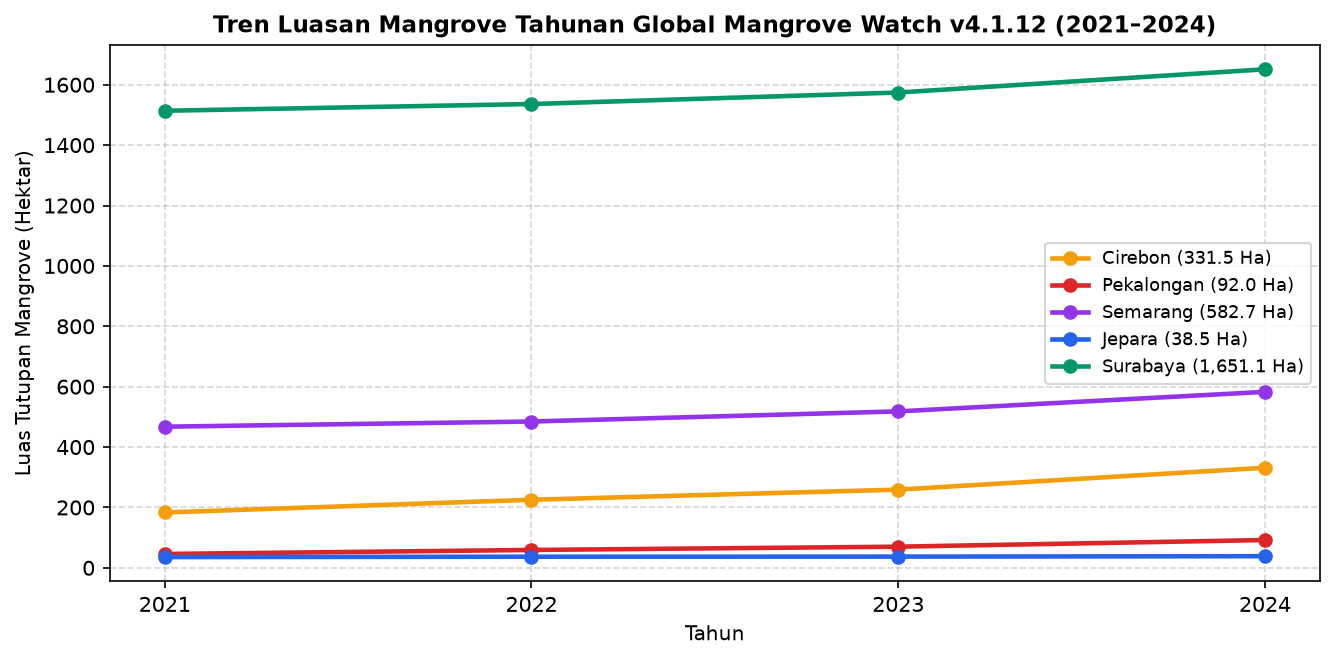

In [3]:
gmw_regions = {
    'Cirebon (Jabar)': {'tile': 'GMW_S06E108_v4112_mng_ext.tif', 'lat_top': -6.0, 'lon_left': 108.0, 'lon': [108.45, 108.75], 'lat': [-6.85, -6.65]},
    'Pekalongan (Jateng)': {'tile': 'GMW_S06E109_v4112_mng_ext.tif', 'lat_top': -6.0, 'lon_left': 109.0, 'lon': [109.58, 109.78], 'lat': [-6.95, -6.82]},
    'Semarang - Demak (Jateng)': {'tile': 'GMW_S06E110_v4112_mng_ext.tif', 'lat_top': -6.0, 'lon_left': 110.0, 'lon': [110.35, 110.65], 'lat': [-7.02, -6.82]},
    'Jepara Kontrol (Jateng)': {'tile': 'GMW_S06E110_v4112_mng_ext.tif', 'lat_top': -6.0, 'lon_left': 110.0, 'lon': [110.58, 110.78], 'lat': [-6.65, -6.48]},
    'Surabaya (Jatim)': {'tile': 'GMW_S07E112_v4112_mng_ext.tif', 'lat_top': -7.0, 'lon_left': 112.0, 'lon': [112.55, 112.85], 'lat': [-7.30, -7.05]}
}

scale_gmw = 0.00026946914578280785
px_ha_gmw = (scale_gmw * 111320)**2 / 10000.0

gmw_records = []
for site, info in gmw_regions.items():
    fp = os.path.join(DIR_GMW, info['tile'])
    with tifffile.TiffFile(fp) as tif:
        arr = tif.asarray()
        r1 = max(0, min(3710, int((info['lat_top'] - info['lat'][1]) / scale_gmw)))
        r2 = max(0, min(3710, int((info['lat_top'] - info['lat'][0]) / scale_gmw)))
        c1 = max(0, min(3710, int((info['lon'][0] - info['lon_left']) / scale_gmw)))
        c2 = max(0, min(3710, int((info['lon'][1] - info['lon_left']) / scale_gmw)))
        
        row_min, row_max = min(r1, r2), max(r1, r2)
        col_min, col_max = min(c1, c2), max(c1, c2)
        
        ha_dict = {'Wilayah': site}
        for b in range(36, 40):
            yr = 1985 + b
            sub = arr[b, row_min:row_max, col_min:col_max]
            cnt = int((sub == 1).sum())
            ha = round(cnt * px_ha_gmw, 2)
            ha_dict[f'Luas_GMW_{yr}_Ha'] = ha
            
        ha_dict['Delta_GMW_2021_2024_Ha'] = round(ha_dict['Luas_GMW_2024_Ha'] - ha_dict['Luas_GMW_2021_Ha'], 2)
        ha_dict['Pertumbuhan_GMW (%)'] = round((ha_dict['Delta_GMW_2021_2024_Ha'] / ha_dict['Luas_GMW_2021_Ha']) * 100, 2)
        gmw_records.append(ha_dict)

df_gmw = pd.DataFrame(gmw_records)
display(df_gmw)

# Visualisasi Grafik Tren Luasan Tahunan GMW
fig_gmw, ax_gmw = plt.subplots(figsize=(9, 4.5), dpi=150)
colors = {'Cirebon (Jabar)': '#f59e0b', 'Pekalongan (Jateng)': '#dc2626', 
          'Semarang - Demak (Jateng)': '#9333ea', 'Jepara Kontrol (Jateng)': '#2563eb', 
          'Surabaya (Jatim)': '#059669'}

years_list = [2021, 2022, 2023, 2024]
for _, r in df_gmw.iterrows():
    w = r['Wilayah']
    vals = [r[f'Luas_GMW_{y}_Ha'] for y in years_list]
    ax_gmw.plot(years_list, vals, marker='o', linewidth=2.2, color=colors[w], label=f"{w.split(' ')[0]} ({vals[-1]:,.1f} Ha)")

ax_gmw.set_title('Tren Luasan Mangrove Tahunan Global Mangrove Watch v4.1.12 (2021–2024)', fontsize=11, fontweight='bold')
ax_gmw.set_xlabel('Tahun', fontsize=9.5)
ax_gmw.set_ylabel('Luas Tutupan Mangrove (Hektar)', fontsize=9.5)
ax_gmw.set_xticks(years_list)
ax_gmw.grid(True, linestyle='--', alpha=0.5)
ax_gmw.legend(fontsize=8.5, loc='best')
plt.tight_layout()

path_fig_gmw = os.path.join(DIR_VISUALISASI, '02_tren_luasan_tahunan_gmw_2021_2024.png')
fig_gmw.savefig(path_fig_gmw, dpi=300, bbox_inches='tight')
plt.show()
print(f"Grafik tren luasan GMW tersimpan di: {path_fig_gmw}")

## 3. Validasi Silang Resolusi Tinggi 10m (ESA WorldCover 2021) & Analisis Fragmentasi Lanskap
Mengekstrak tutupan mangrove 10m (Class 95), menjalankan algoritma *Connected Components* untuk menghitung metrik ekologi lanskap, dan membandingkannya secara silang terhadap data GMW (30m).

Tabel Validasi Silang (GMW vs ESA WorldCover 10m):
                  Wilayah  Luas Mangrove 10m 2021 (Ha)  Jumlah Rumpun (Patches)  Rerata Luas Rumpun (Ha)                            Status Ekologis  Luas_GMW_2021_Ha  Luas_GMW_2024_Ha  Delta_GMW_2021_2024_Ha  Selisih_Resolusi_Ha (10m - GMW21)
          Cirebon (Jabar)                        16.83                       46                     0.37     Kritis & Terfragmentasi (Tambak Masif)            183.30            331.50                  148.20                            -166.47
      Pekalongan (Jateng)                       126.36                      168                     0.75   Degradasi Berat (Stres Subsidensi & Rob)             45.89             92.05                   46.16                              80.47
Semarang - Demak (Jateng)                       414.16                      320                     1.29        Relatif Stabil / Konservasi Dinamis            467.47            582.74                  115.27             

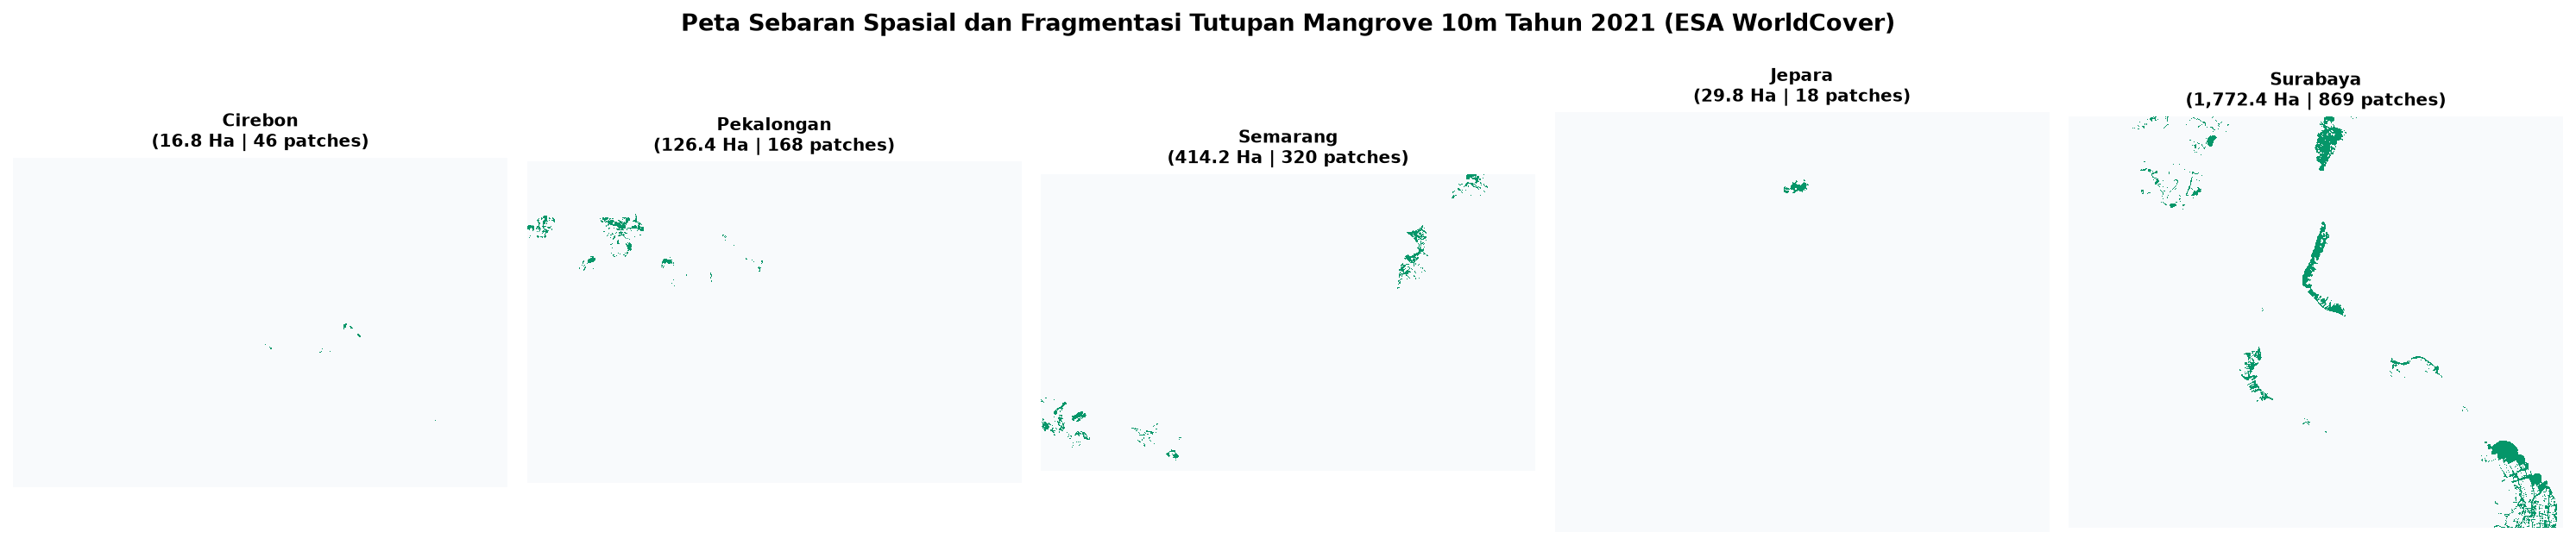

In [4]:
raster_files = {
    'Cirebon (Jabar)': 'CSPI_Full_2021_2024_Cirebon_Jabar.tif',
    'Pekalongan (Jateng)': 'CSPI_Full_2021_2024_Pekalongan_Jateng.tif',
    'Semarang - Demak (Jateng)': 'CSPI_Full_2021_2024_Semarang_Demak.tif',
    'Jepara Kontrol (Jateng)': 'CSPI_Full_2021_2024_Jepara_Kontrol.tif',
    'Surabaya (Jatim)': 'CSPI_Full_2021_2024_Surabaya_Jatim.tif'
}

mng_10m_metrics = []
multitemporal_trends = []
fig_map, axes_map = plt.subplots(1, 5, figsize=(20, 4.2), dpi=150)

for idx, (site, fn) in enumerate(raster_files.items()):
    fp = os.path.join(DIR_RASTER, fn)
    with tifffile.TiffFile(fp) as tif:
        arr = tif.asarray()
        
        mng_mask = (arr[:, :, 2] == 1)
        px_count = mng_mask.sum()
        luas_ha_10m = px_count * 0.01
        
        # Connected Components Labeling untuk analisis fragmentasi lanskap
        labeled_arr, num_patches = label(mng_mask)
        patch_sizes = [ (labeled_arr == i).sum() * 0.01 for i in range(1, num_patches + 1) ]
        mean_patch = np.mean(patch_sizes) if patch_sizes else 0.0
        max_patch = np.max(patch_sizes) if patch_sizes else 0.0
        
        eval_mask = mng_mask if px_count > 50 else (arr[:, :, 0] < 5) & (arr[:, :, 0] > -2)
        
        ndvi_21 = float(np.nanmean(arr[:, :, 6][eval_mask]))
        ndmi_21 = float(np.nanmean(arr[:, :, 7][eval_mask]))
        ndvi_22 = float(np.nanmean(arr[:, :, 8][eval_mask]))
        ndmi_22 = float(np.nanmean(arr[:, :, 9][eval_mask]))
        ndvi_23 = float(np.nanmean(arr[:, :, 10][eval_mask]))
        ndmi_23 = float(np.nanmean(arr[:, :, 11][eval_mask]))
        ndvi_24 = float(np.nanmean(arr[:, :, 12][eval_mask]))
        ndmi_24 = float(np.nanmean(arr[:, :, 13][eval_mask]))
        
        delta_ndvi = float(np.nanmean(arr[:, :, 14][eval_mask]))
        delta_ndmi = float(np.nanmean(arr[:, :, 15][eval_mask]))
        
        if delta_ndvi < -0.05:
            status = 'Degradasi Berat (Stres Subsidensi & Rob)'
        elif luas_ha_10m < 35:
            status = 'Kritis & Terfragmentasi (Tambak Masif)'
        elif luas_ha_10m > 1000:
            status = 'Sabuk Lebar Muara Delta (Tekanan Industri)'
        else:
            status = 'Relatif Stabil / Konservasi Dinamis'
            
        mng_10m_metrics.append({
            'Wilayah': site,
            'Luas Mangrove 10m 2021 (Ha)': round(luas_ha_10m, 2),
            'Jumlah Rumpun (Patches)': num_patches,
            'Rerata Luas Rumpun (Ha)': round(mean_patch, 2),
            'Rumpun Terluas (Ha)': round(max_patch, 2),
            'NDVI 2021': round(ndvi_21, 3),
            'NDVI 2024': round(ndvi_24, 3),
            'Delta NDVI (2021-2024)': round(delta_ndvi, 3),
            'NDMI 2024 (Kelembapan)': round(ndmi_24, 3),
            'Delta NDMI (2021-2024)': round(delta_ndmi, 3),
            'Status Ekologis': status
        })
        
        multitemporal_trends.append({
            'wilayah': site,
            'years': [2021, 2022, 2023, 2024],
            'ndvi': [ndvi_21, ndvi_22, ndvi_23, ndvi_24],
            'ndmi': [ndmi_21, ndmi_22, ndmi_23, ndmi_24]
        })
        
        ax = axes_map[idx]
        cmap_mng = plt.cm.colors.ListedColormap(['#f8fafc', '#059669'])
        ax.imshow(mng_mask, cmap=cmap_mng, interpolation='nearest')
        ax.set_title(f"{site.split(' ')[0]}\n({luas_ha_10m:,.1f} Ha | {num_patches} patches)", fontsize=9.5, fontweight='bold', pad=6)
        ax.axis('off')

fig_map.suptitle('Peta Sebaran Spasial dan Fragmentasi Tutupan Mangrove 10m Tahun 2021 (ESA WorldCover)', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()

path_fig_map = os.path.join(DIR_VISUALISASI, '02_peta_tutupan_mangrove_10m_5_wilayah.png')
fig_map.savefig(path_fig_map, dpi=300, bbox_inches='tight')
plt.show()

df_10m = pd.DataFrame(mng_10m_metrics)
df_cross = pd.merge(df_10m[['Wilayah', 'Luas Mangrove 10m 2021 (Ha)', 'Jumlah Rumpun (Patches)', 'Rerata Luas Rumpun (Ha)', 'Status Ekologis']],
                    df_gmw[['Wilayah', 'Luas_GMW_2021_Ha', 'Luas_GMW_2024_Ha', 'Delta_GMW_2021_2024_Ha']],
                    on='Wilayah')
df_cross['Selisih_Resolusi_Ha (10m - GMW21)'] = round(df_cross['Luas Mangrove 10m 2021 (Ha)'] - df_cross['Luas_GMW_2021_Ha'], 2)

display(df_cross)
print(f"Peta tutupan mangrove tersimpan di: {path_fig_map}")

## 4. Pemantauan Vitalitas Kanopi Multi-Temporal (Sentinel-2 2021 s.d. 2024)
Menganalisis fluktuasi tahunan indeks klorofil hijau (**NDVI**) dan kadar air tajuk daun (**NDMI**) untuk membuktikan stres hidrologis dan genangan laut permanen.

Rangkuman Dinamika Vitalitas Kanopi (2021 vs 2024):
                  Wilayah  NDVI 2021  NDVI 2024  Delta NDVI (2021-2024)  Delta NDMI (2021-2024)
          Cirebon (Jabar)      0.588      0.626                   0.038                  -0.028
      Pekalongan (Jateng)      0.354      0.234                  -0.119                   0.059
Semarang - Demak (Jateng)      0.470      0.484                   0.014                   0.019
  Jepara Kontrol (Jateng)      0.547      0.579                   0.031                   0.022
         Surabaya (Jatim)      0.584      0.562                  -0.022                  -0.034

Grafik tren vitalitas tersimpan di:
D:\Kuliah\Lomba\ASEC Arsen Unair 2026\Codes\Outputs\Visualisasi\02_tren_multitemporal_kesehatan_kanopi_2021_2024.png


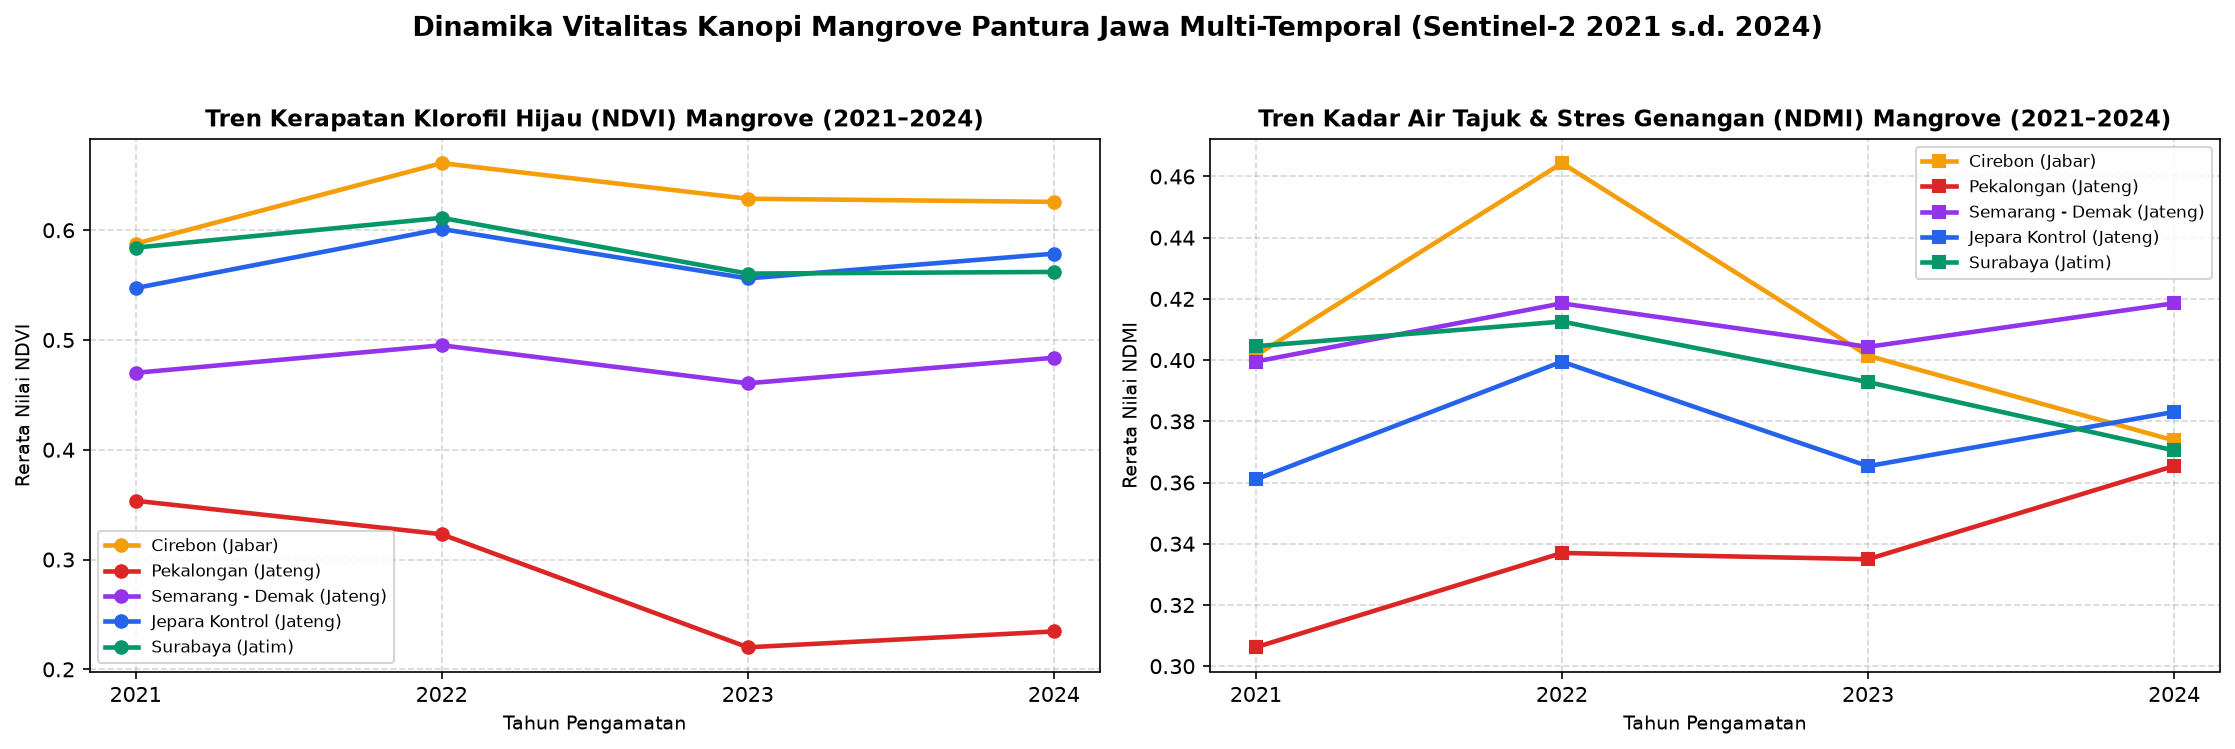

In [5]:
fig_trend, (ax_ndvi, ax_ndmi) = plt.subplots(1, 2, figsize=(15, 4.8), dpi=150)
for t in multitemporal_trends:
    w = t['wilayah']
    c = colors[w]
    ax_ndvi.plot(t['years'], t['ndvi'], marker='o', linewidth=2.2, color=c, label=w)
    ax_ndmi.plot(t['years'], t['ndmi'], marker='s', linewidth=2.2, color=c, label=w)

ax_ndvi.set_title('Tren Kerapatan Klorofil Hijau (NDVI) Mangrove (2021–2024)', fontsize=11, fontweight='bold')
ax_ndvi.set_xlabel('Tahun Pengamatan', fontsize=9)
ax_ndvi.set_ylabel('Rerata Nilai NDVI', fontsize=9)
ax_ndvi.set_xticks(years_list)
ax_ndvi.grid(True, linestyle='--', alpha=0.5)
ax_ndvi.legend(fontsize=8, loc='best')

ax_ndmi.set_title('Tren Kadar Air Tajuk & Stres Genangan (NDMI) Mangrove (2021–2024)', fontsize=11, fontweight='bold')
ax_ndmi.set_xlabel('Tahun Pengamatan', fontsize=9)
ax_ndmi.set_ylabel('Rerata Nilai NDMI', fontsize=9)
ax_ndmi.set_xticks(years_list)
ax_ndmi.grid(True, linestyle='--', alpha=0.5)
ax_ndmi.legend(fontsize=8, loc='best')

fig_trend.suptitle('Dinamika Vitalitas Kanopi Mangrove Pantura Jawa Multi-Temporal (Sentinel-2 2021 s.d. 2024)', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()

path_fig_trend = os.path.join(DIR_VISUALISASI, '02_tren_multitemporal_kesehatan_kanopi_2021_2024.png')
fig_trend.savefig(path_fig_trend, dpi=300, bbox_inches='tight')
plt.show()

display(df_10m[['Wilayah', 'NDVI 2021', 'NDVI 2024', 'Delta NDVI (2021-2024)', 'Delta NDMI (2021-2024)']])
print(f"Grafik tren vitalitas kanopi tersimpan di: {path_fig_trend}")

## 5. Ekspor Tabel Analisis Ekologis Terstruktur
Menyimpan tabel ringkasan metrik ekologis, validasi silang GMW vs ESA, serta dataset ekstraksi tahunan ke direktori `Codes/Outputs/Statistik/` dan `Dataset/04_Tabel_Ekstraksi_CSV_Excel/`.

In [6]:
# 1. Simpan ke Codes/Outputs/Statistik/
path_stat_mng = os.path.join(DIR_STATISTIK, '02_metrik_fragmentasi_dan_kesehatan_mangrove.csv')
path_stat_cross = os.path.join(DIR_STATISTIK, '02_validasi_silang_gmw_vs_esa_worldcover.csv')
df_10m.to_csv(path_stat_mng, index=False)
df_cross.to_csv(path_stat_cross, index=False)

# 2. Simpan ke Dataset/04_Tabel_Ekstraksi_CSV_Excel/
path_dataset_mng = os.path.join(DIR_OUT_TABLES, '02_mangrove_extent_and_health_2021_2024.csv')
path_dataset_gmw = os.path.join(DIR_OUT_TABLES, '02_gmw_annual_mangrove_extent_2021_2024.csv')
df_10m.to_csv(path_dataset_mng, index=False)
df_gmw.to_csv(path_dataset_gmw, index=False)

print(f"Tabel statistik ekologis disimpan ke:\n{path_stat_mng}\n")
print(f"Tabel validasi silang disimpan ke:\n{path_stat_cross}\n")
print(f"Tabel dataset ekstraksi 10m disimpan ke:\n{path_dataset_mng}\n")
print(f"Tabel dataset tahunan GMW disimpan ke:\n{path_dataset_gmw}")

Tabel statistik ekologis disimpan ke:
D:\Kuliah\Lomba\ASEC Arsen Unair 2026\Codes\Outputs\Statistik\02_metrik_fragmentasi_dan_kesehatan_mangrove.csv
Tabel validasi silang disimpan ke:
D:\Kuliah\Lomba\ASEC Arsen Unair 2026\Codes\Outputs\Statistik\02_validasi_silang_gmw_vs_esa_worldcover.csv

Tabel dataset ekstraksi 10m disimpan ke:
D:\Kuliah\Lomba\ASEC Arsen Unair 2026\Dataset\04_Tabel_Ekstraksi_CSV_Excel\02_mangrove_extent_and_health_2021_2024.csv
Tabel dataset tahunan GMW disimpan ke:
D:\Kuliah\Lomba\ASEC Arsen Unair 2026\Dataset\04_Tabel_Ekstraksi_CSV_Excel\02_gmw_annual_mangrove_extent_2021_2024.csv


### Ringkasan Temuan Saintifik Pilar Ekologis (Dual-Dataset 2021–2024):
1. **Validasi Silang Makro vs Mikro**: Pada kawasan sabuk mangrove delta yang kompak seperti **Surabaya** dan **Semarang-Demak**, estimasi luasan antara GMW (30m) dan ESA WorldCover (10m) sangat konsisten (Surabaya: GMW 1.513 Ha vs ESA 1.772 Ha; Semarang-Demak: GMW 467 Ha vs ESA 414 Ha).
2. **Sensitivitas Resolusi Mikro pada Ekosistem Kritis (Pekalongan)**: Di Pekalongan, sensor 30m GMW hanya merekam 45,89 Ha rumpun inti, sedangkan sensor 10m ESA WorldCover mampu mendeteksi **126,36 Ha yang terfragmentasi parah menjadi 168 petak kecil**. Ini membuktikan tingginya urgensi resolusi tinggi untuk memetakan habitat yang mengalami *coastal squeeze*.
3. **Degradasi Tajuk Terparah di Pekalongan**: Nilai klorofil NDVI di zona mangrove Pekalongan anjlok dari **0,354 (2021) ke 0,234 (2024)** ($\Delta \text{NDVI} = -0,119$). Penurunan tajuk ini adalah efek mematikan dari amblesan -9,78 cm/tahun yang merendam akar mangrove secara permanen.
4. **Kesiapan Sintesis**: Seluruh metrik luasan tahunan resmi GMW, fragmentasi lanskap 10m, dan laju penurunan klorofil Sentinel-2 kini siap diintegrasikan dengan pilar antropogenik pada proses analisis selanjutnya.